In [12]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np

In [13]:
torch.set_default_device('cuda')

In [14]:
import sys
import os

# Determina o caminho base do projeto: 
# CWD geralmente é onde o Notebook está. 
# Se o Notebook está em 'src/scripts', subimos dois níveis para a raiz.
current_dir = os.getcwd() 

# 1. Caminho para 'utils': Sobe dois níveis e entra em 'src/utils'
utils_path = os.path.abspath(os.path.join(current_dir, '..', '..', 'src', 'utils'))

# 2. Caminho para 'models': Sobe dois níveis e entra em 'src/models'
models_path = os.path.abspath(os.path.join(current_dir, '..', '..', 'src', 'models'))

# Adiciona ao path do sistema
sys.path.append(utils_path)
sys.path.append(models_path)

print(f"Adicionado ao PATH: {utils_path}")
print(f"Adicionado ao PATH: {models_path}")

# Importações agora devem funcionar:
import torch
import torch.nn as nn
# ... (O restante dos seus imports)
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, ConcatDataset

from StaticMaskTraining import StaticMaskTraining

from TrainingConfig import TrainingConfig
from LambdaScheduler import LambdaScheduler
from TotalLoss import TotalLoss

from LeNet5 import LeNet5
import SelectionMask as sm


Adicionado ao PATH: /home/andre-marques/Desktop/Estudo/PowerRangersCode/src/utils
Adicionado ao PATH: /home/andre-marques/Desktop/Estudo/PowerRangersCode/src/models


In [15]:
def load_checkpoints(training_id):
    i = 0
    while True:
        try: 
            state_dict = torch.load(f"../../checkpoints/{training_id}/checkpoint_epoch_{i + 1}.pt", map_location='cpu')
            yield state_dict
            del state_dict
            torch.cuda.empty_cache()
            i += 1
        except FileNotFoundError:
            break

In [16]:
import torch
import os
import numpy as np # Necessário para np.inf, etc.

def load_checkpoints(training_id):
    """
    Simula o carregamento iterativo de checkpoints de uma sessão de treinamento.
    Assume que os arquivos estão nomeados como 'checkpoint_epoch_1.pt', etc.
    """
    i = 0
    while True:
        i += 1
        # Assumindo que você está em 'src/scripts' e os checkpoints estão em '../../checkpoints/'
        checkpoint_path = os.path.abspath(os.path.join(
            os.getcwd(), '..', '..', 'checkpoints', training_id, f'checkpoint_epoch_{i}.pt'
        ))
        
        if not os.path.exists(checkpoint_path):
            if i == 1:
                print(f"Nenhum checkpoint encontrado para o ID '{training_id}'. Verifique o caminho.")
            break
            
        try:
            # CORREÇÃO ESSENCIAL: Permite carregar dados do NumPy e evitar o UnpicklingError
            state_dict = torch.load(
                checkpoint_path, 
                map_location='cpu',
                weights_only=False 
            )
            yield state_dict
            
        except Exception as e:
            print(f"Erro ao carregar o checkpoint da época {i} em {checkpoint_path}: {e}")
            break

# --- O código abaixo é apenas para fins de DEBUG/Confirmação de Caminho ---
# print(os.path.abspath(os.path.join(os.getcwd(), '..', '..', 'checkpoints')))
# --------------------------------------------------------------------------

# Execute esta célula antes de tentar plotar.

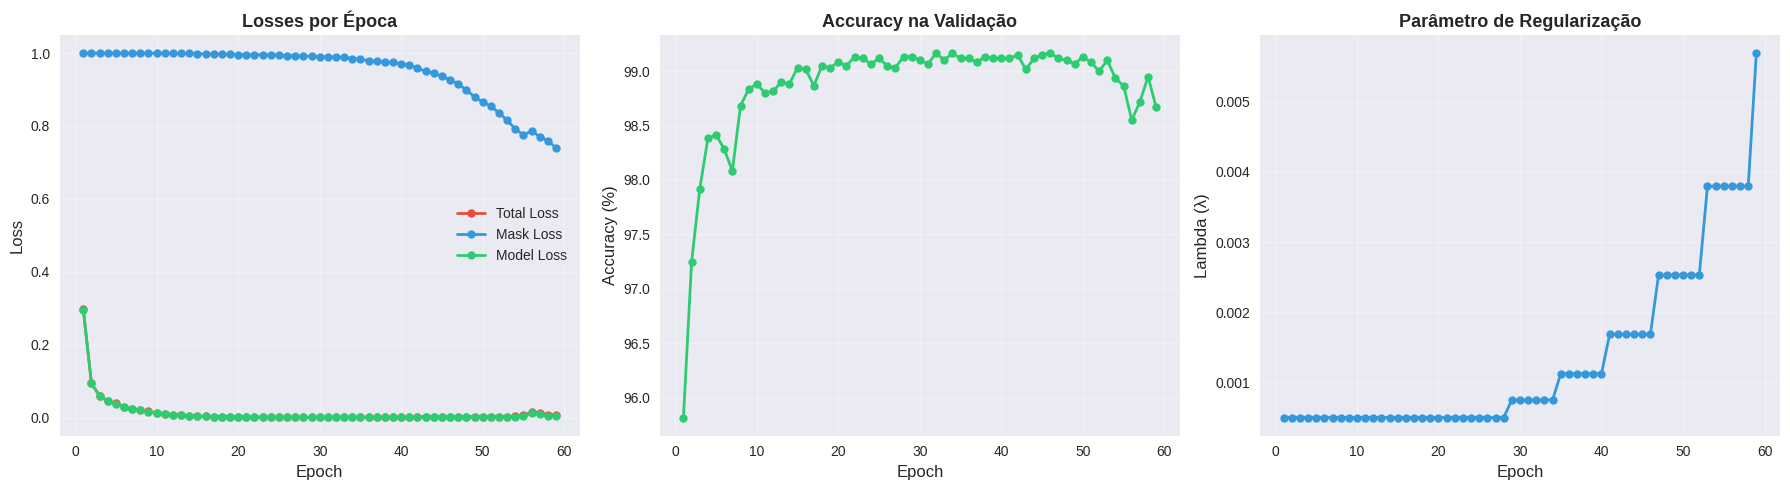

In [17]:
import matplotlib.pyplot as plt
import numpy as np
import math

# --- 1. COLETA DE DADOS (Mantida) ---
epochs = []
total_losses = []
accuracies = []
lambdas = []
mask_loss = []
model_loss = []

# Nota: Certifique-se de que load_checkpoints("lenet_mnist_01") está acessível e funcional
for check in load_checkpoints("lenet_mnist_01"):
    epochs.append(check['epoch'])
    total_losses.append(check['total_loss'])
    accuracies.append(check['accuracy'])
    lambdas.append(check['lambda'])
    mask_loss.append(check['mask_loss'])
    model_loss.append(check['model_loss'])

# O 'relations' foi ignorado conforme solicitado.

# --- 2. CONFIGURAÇÃO DA PLOTAGEM ---
plt.style.use('seaborn-v0_8')
# Alterado para 1 linha e 3 colunas
fig, axes = plt.subplots(1, 3, figsize=(18, 5)) 


# =========================================================================
# GRÁFICO 1 (axes[0]): Total Loss + Mask Loss + Model Loss
# =========================================================================
axes[0].plot(epochs, total_losses, 'o-', color='#e74c3c', linewidth=2, markersize=6, label='Total Loss')
axes[0].plot(epochs, mask_loss,   'o-', color='#3498db', linewidth=2, markersize=6, label='Mask Loss')
axes[0].plot(epochs, model_loss,  'o-', color='#2ecc71', linewidth=2, markersize=6, label='Model Loss')

axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Loss', fontsize=12)
axes[0].set_title('Losses por Época', fontsize=13, fontweight='bold')
axes[0].grid(True, alpha=0.3)
axes[0].legend(fontsize=10)


# =========================================================================
# GRÁFICO 2 (axes[1]): Accuracy
# =========================================================================
axes[1].plot(epochs, accuracies, 'o-', color='#2ecc71', linewidth=2, markersize=6)
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Accuracy (%)', fontsize=12)
axes[1].set_title('Accuracy na Validação', fontsize=13, fontweight='bold')
axes[1].grid(True, alpha=0.3)


# =========================================================================
# GRÁFICO 3 (axes[2]): Lambda (λ)
# =========================================================================
axes[2].plot(epochs, lambdas, 'o-', color='#3498db', linewidth=2, markersize=6)
axes[2].set_xlabel('Epoch', fontsize=12)
axes[2].set_ylabel('Lambda (λ)', fontsize=12)
axes[2].set_title('Parâmetro de Regularização', fontsize=13, fontweight='bold')
axes[2].grid(True, alpha=0.3)


# --- 3. FINALIZAÇÃO ---
plt.tight_layout() # Ajusta automaticamente o espaçamento para evitar sobreposição
plt.show()